## EDA With Red Wine Data

Data Set Information:

The two datasets are related to red and white variants of the Portuguese "Vinho Verde" wine.  Due to privacy and logistic issues, only physicochemical (inputs) and sensory (the output) variables are available (e.g. there is no data about grape types, wine brand, wine selling price, etc.).

These datasets can be viewed as classification or regression tasks. The classes are ordered and not balanced (e.g. there are many more normal wines than excellent or poor ones). Outlier detection algorithms could be used to detect the few excellent or poor wines. Also, we are not sure if all input variables are relevant. So it could be interesting to test feature selection methods.


Attribute Information:

Input variables (based on physicochemical tests):
- 1 - fixed acidity
- 2 - volatile acidity
- 3 - citric acid
- 4 - residual sugar
- 5 - chlorides
- 6 - free sulfur dioxide
- 7 - total sulfur dioxide
- 8 - density
- 9 - pH
- 10 - sulphates
- 11 - alcohol

Output variable (based on sensory data):
- 12 - quality (score between 0 and 10)

## Objective

The goal of this analysis is to explore the Wine Quality dataset, understand key patterns, identify important features, and prepare insights for future machine learning modeling.

### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

### 2. Load Dataset

In [2]:
wine_quality = pd.read_csv('winequality-red.csv')
wine_quality.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### 3. Basic Overview

In [3]:
wine_quality.shape

(1143, 12)

In [4]:
wine_quality.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [5]:
wine_quality.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### **Insights**
Dataset contains physicochemical properties of wine samples

Target variable: quality (ordinal score)

### 4. Data Cleaning

#### Missing Values

In [6]:
wine_quality.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

#### Duplicates

In [7]:
wine_quality.duplicated().sum()

np.int64(125)

In [8]:
wine_quality = wine_quality.drop_duplicates()

#### **Insights**
Duplicate rows were removed to avoid bias

### 5. Target Variable Analysis

In [9]:
wine_quality.quality.value_counts().sort_values()

quality
3      6
8     15
4     33
7    122
6    409
5    433
Name: count, dtype: int64

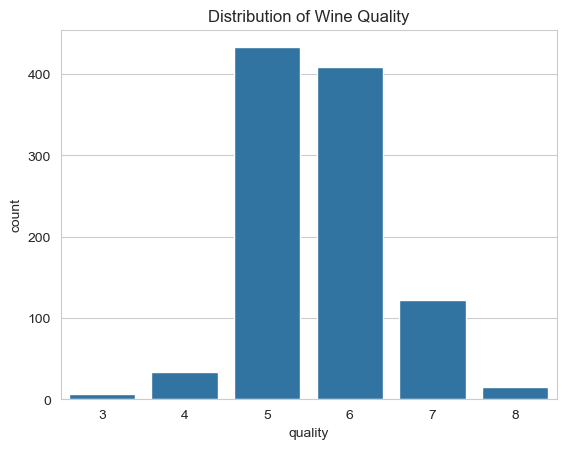

In [10]:
sns.countplot(x='quality',data=wine_quality)
plt.title('Distribution of Wine Quality')
plt.show()

#### **Insights**
Dataset is imbalanced

Most wines fall between quality 5–6

High-quality wines are underrepresented

### 6. Univariate Analysis

#### Distribution of Features

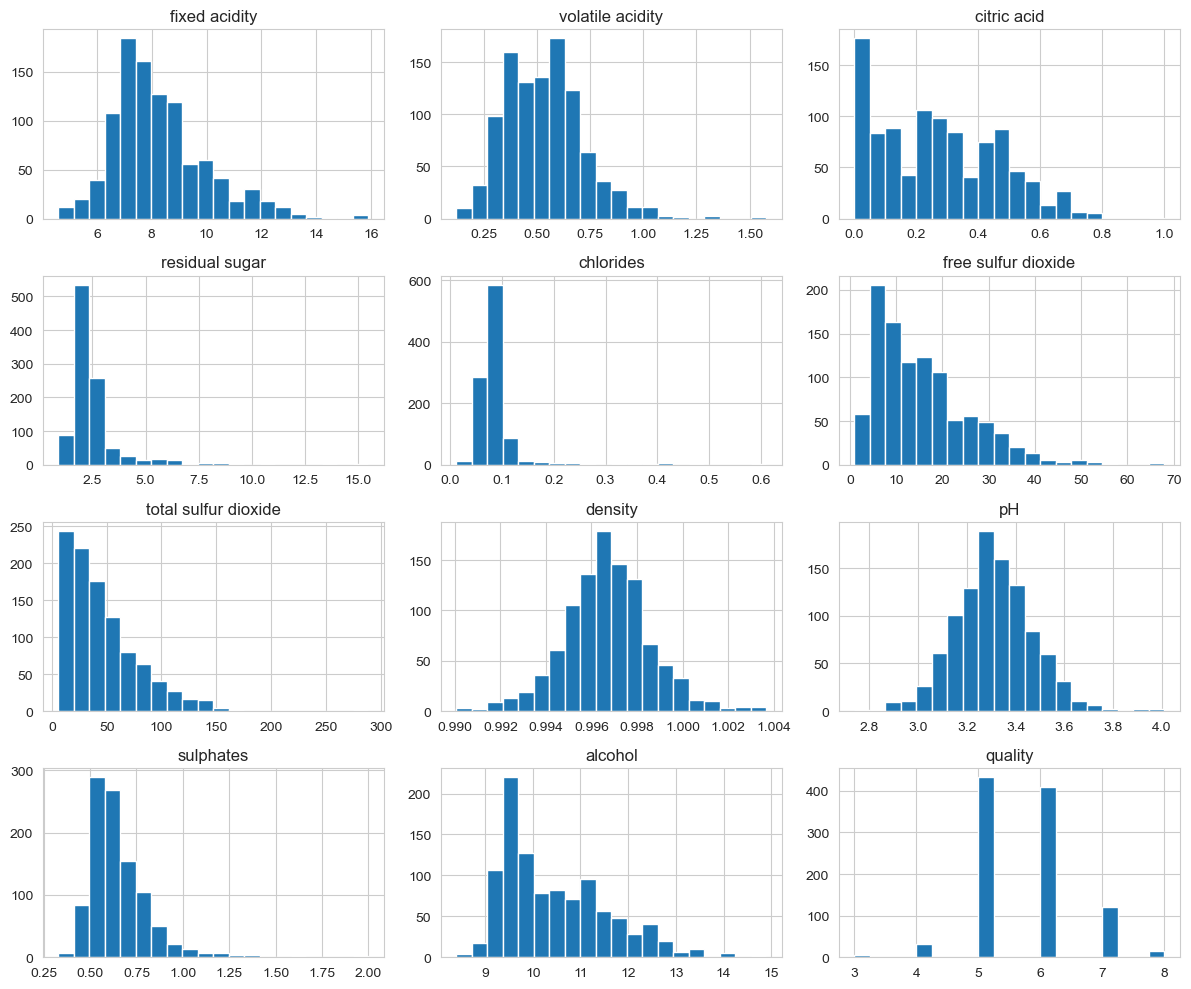

In [11]:
wine_quality.hist(figsize=(12,10),bins=20)
plt.tight_layout()
plt.show()

#### **Insights**
Many features show skewness

Some variables contain potential outliers

### 7. Outlier Detection

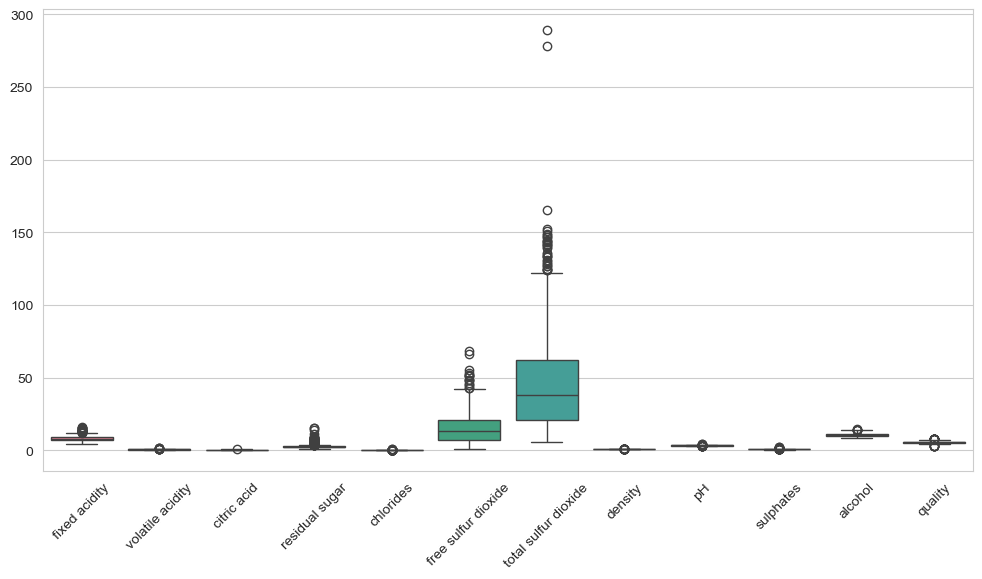

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=wine_quality)
plt.xticks(rotation=45)
plt.show()

#### **Insights**
Outliers present in multiple features

### 8. Correlation Analysis

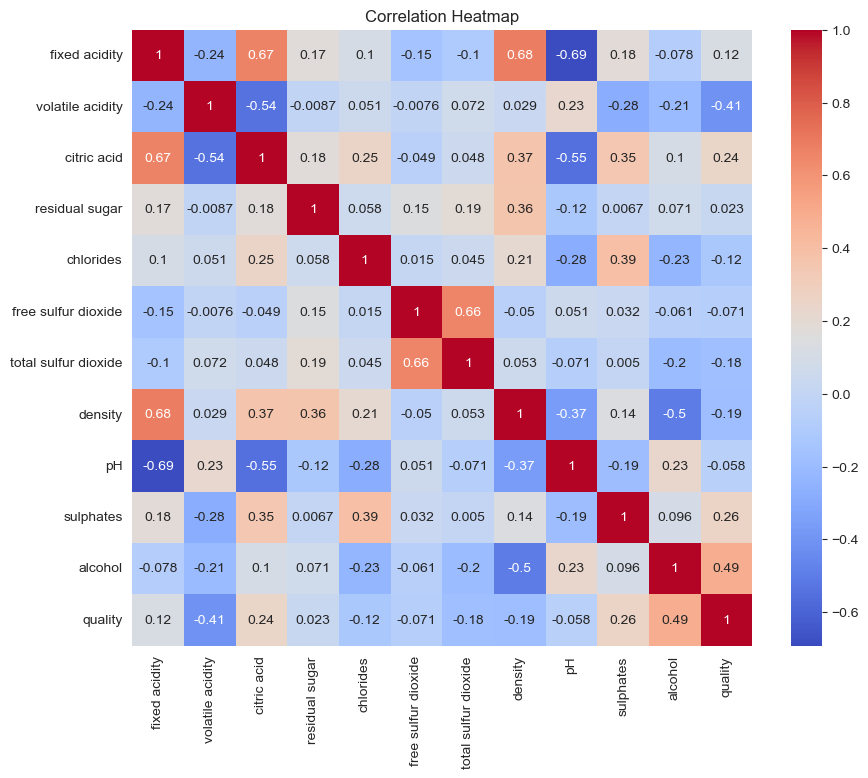

In [13]:
plt.figure(figsize=(10,8))
sns.heatmap(wine_quality.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

#### Key Findings
**Alcohol** has strong positive correlation with quality

**Volatile acidity** shows negative correlation with quality

Some multicollinearity exists between features

### 9. Feature vs Target Analysis

#### Alcohol vs Quality

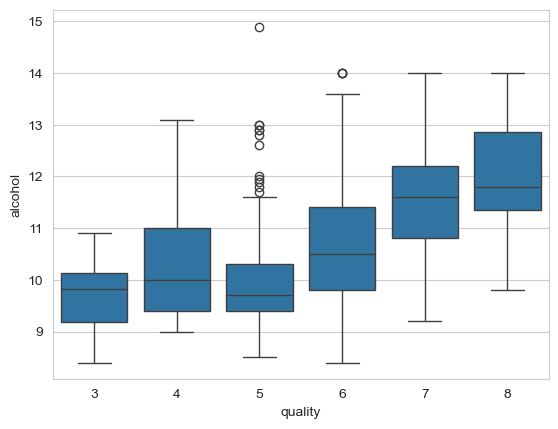

In [14]:
sns.boxplot(x='quality',y='alcohol',data=wine_quality)
plt.show()

#### Volatile Acidity vs Quality

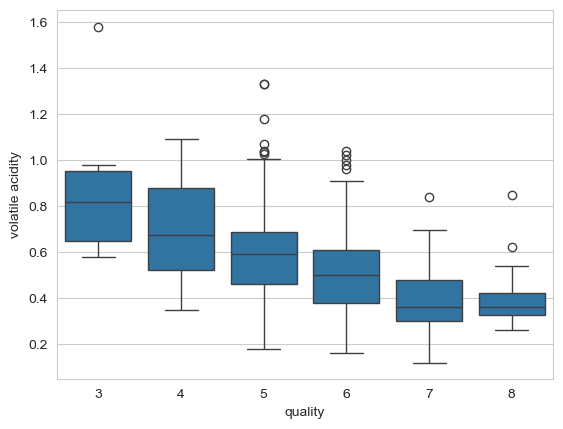

In [15]:
sns.boxplot(x='quality',y='volatile acidity',data=wine_quality)
plt.show()

## **Insights**
Higher alcohol content -> higher quality wines

Higher volatile acidity -> lower quality wines

### 10. Pairwise Relationships

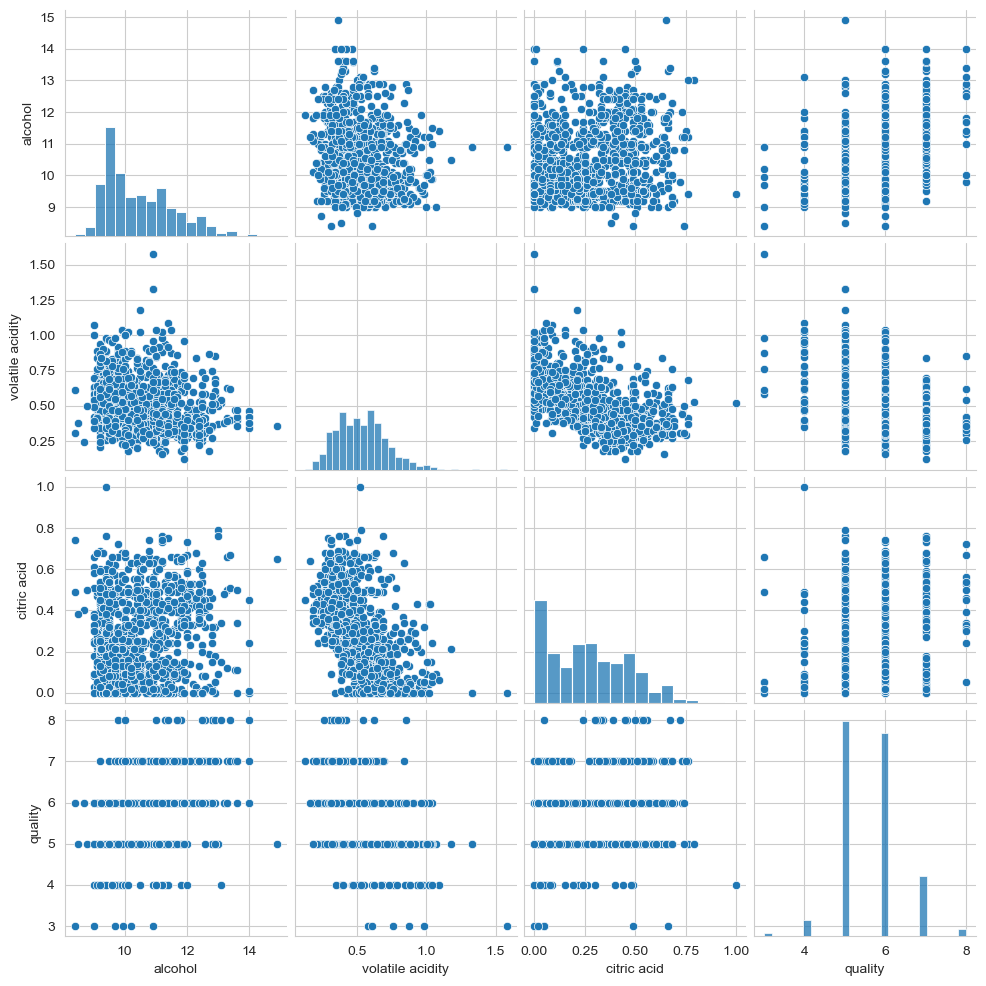

In [16]:
sns.pairplot(data=wine_quality[['alcohol','volatile acidity','citric acid','quality']])
plt.show()

#### **Insights**
Confirms trends observed in correlation analysis

### 11. Final conclusions

#### **Key Features**
**Alcohol** -> positive impact

**Volatile Acidity** -> negative impact

**Citric Acid** -> moderate influence

#### **Data Issues**
Imbalanced target variable

Presence of outliers

Skewed distributions